In [20]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.optimize import minimize_scalar
from scipy.stats import norm

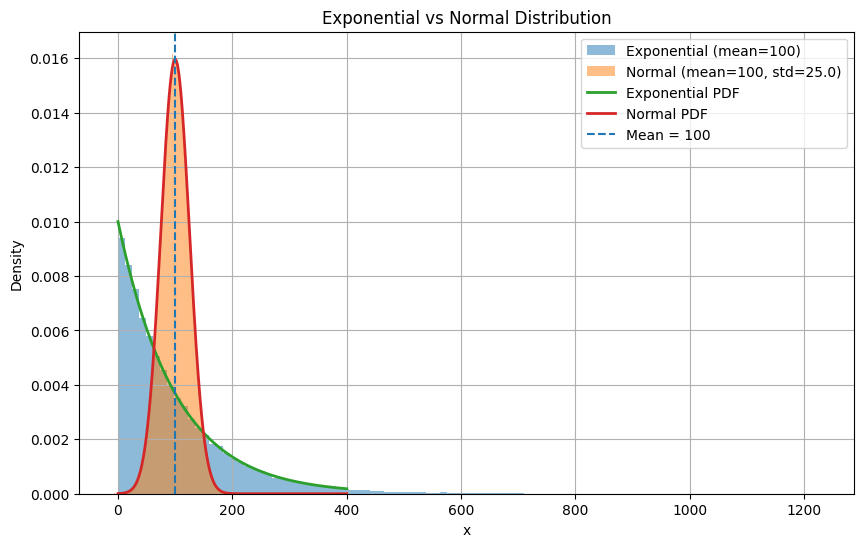

Exponential:
 Mean = 99.30164999029515
 Std  = 99.18110955973471

Normal:
 Mean = 100.1450692563101
 Std  = 25.021932757890244


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon, norm

# ==========================
# Parameters
# ==========================

b = 100          # desired mean
n = 100000       # number of samples

# ==========================
# Generate samples
# ==========================

# Exponential distribution
# mean = scale
exp_samples = np.random.exponential(scale=b, size=n)

# Normal distribution
# mean = b
# std = b/4
normal_samples = np.random.normal(
    loc=b,
    scale=b/4,
    size=n
)

# ==========================
# Plot
# ==========================

x = np.linspace(0, 4*b, 1000)

plt.figure(figsize=(10, 6))

# Histograms
plt.hist(
    exp_samples,
    bins=100,
    density=True,
    alpha=0.5,
    label=f"Exponential (mean={b})"
)

plt.hist(
    normal_samples,
    bins=100,
    density=True,
    alpha=0.5,
    label=f"Normal (mean={b}, std={b/4})"
)

# Theoretical PDFs
plt.plot(
    x,
    expon.pdf(x, scale=b),
    linewidth=2,
    label="Exponential PDF"
)

plt.plot(
    x,
    norm.pdf(x, loc=b, scale=b/4),
    linewidth=2,
    label="Normal PDF"
)

plt.axvline(b, linestyle="--", label=f"Mean = {b}")

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Exponential vs Normal Distribution")
plt.legend()
plt.grid(True)
plt.show()

# ==========================
# Verify moments
# ==========================

print("Exponential:")
print(" Mean =", np.mean(exp_samples))
print(" Std  =", np.std(exp_samples))

print("\nNormal:")
print(" Mean =", np.mean(normal_samples))
print(" Std  =", np.std(normal_samples))

In [22]:
e = 392
a = e/5

def accept_prob_uniform(br, b_hat):
    return max(0.0, min(1.0, (b_hat + a - br) / (2 * a)))

def accept_prob_normal(br, b_hat):
    if b_hat == 0:
        return 0.0
    return float(1 - norm.cdf((br - b_hat) / (0.25 * b_hat)))

def accept_prob_exponential(br, b_hat):
    if b_hat == 0:
        return 0.0
    return math.exp(-br / b_hat)

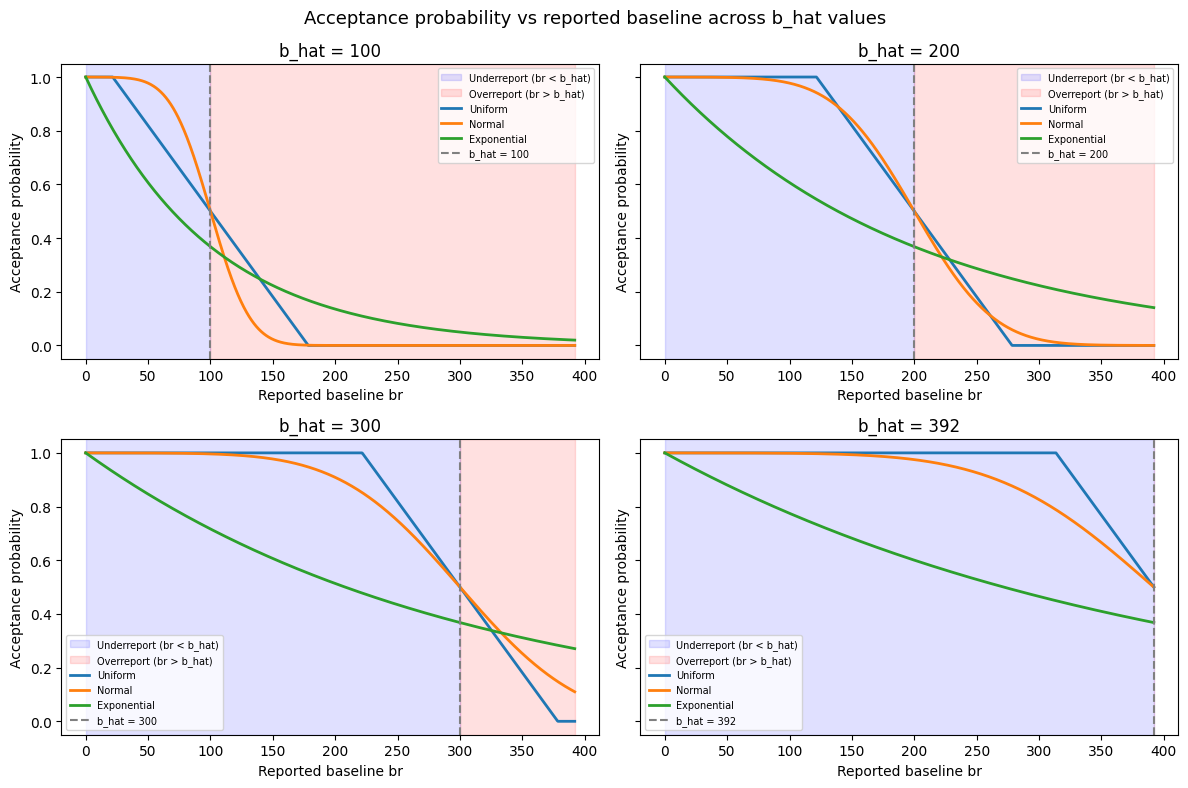

In [27]:
# --- Part 2.1: Acceptance probability for multiple b_hat values ---

b_hat_values = [100, 200, 300, 392]
br_values = np.linspace(0, e, 1001)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.flatten()

for ax, b_hat in zip(axes, b_hat_values):
    prob_uniform = [accept_prob_uniform(br, b_hat) for br in br_values]
    prob_normal  = [accept_prob_normal(br, b_hat)  for br in br_values]
    prob_exp     = [accept_prob_exponential(br, b_hat) for br in br_values]

    # Highlight overreport (br > b_hat) in light red, underreport (br < b_hat) in light blue
    ax.axvspan(0,     b_hat, alpha=0.12, color='blue',  label='Underreport (br < b_hat)')
    ax.axvspan(b_hat, e,     alpha=0.12, color='red',   label='Overreport (br > b_hat)')

    ax.plot(br_values, prob_uniform, label='Uniform',     linewidth=2)
    ax.plot(br_values, prob_normal,  label='Normal',      linewidth=2)
    ax.plot(br_values, prob_exp,     label='Exponential', linewidth=2)
    ax.axvline(b_hat, linestyle='--', color='gray', label=f'b_hat = {b_hat}')
    ax.set_title(f'b_hat = {b_hat}')
    ax.set_xlabel('Reported baseline br')
    ax.set_ylabel('Acceptance probability')
    ax.legend(fontsize=7)


fig.suptitle('Acceptance probability vs reported baseline across b_hat values', fontsize=13)
plt.tight_layout()
plt.savefig('accept_prob_comparison.png', dpi=300)
plt.show()

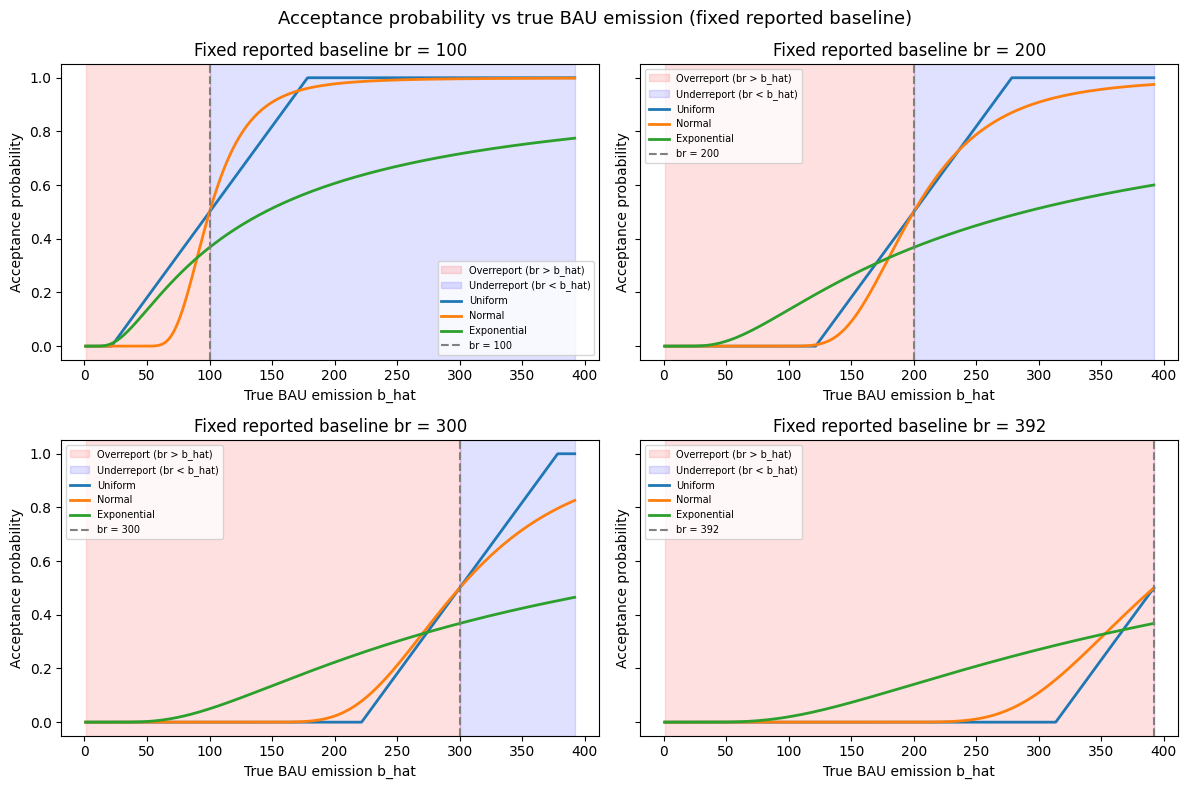

In [28]:
# --- Part 2.2: Acceptance probability for fixed br, varying b_hat ---

br_fixed_values = [100, 200, 300, 392]
b_hat_values_sweep = np.linspace(1, e, 1000)  # avoid b_hat=0 (division by zero)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.flatten()

for ax, br_fixed in zip(axes, br_fixed_values):
    prob_uniform = [accept_prob_uniform(br_fixed, bh) for bh in b_hat_values_sweep]
    prob_normal  = [accept_prob_normal(br_fixed, bh)  for bh in b_hat_values_sweep]
    prob_exp     = [accept_prob_exponential(br_fixed, bh) for bh in b_hat_values_sweep]

    # When b_hat < br: developer overreports (br > b_hat) -> light red
    # When b_hat > br: developer underreports (br < b_hat) -> light blue
    ax.axvspan(1,        br_fixed, alpha=0.12, color='red',  label='Overreport (br > b_hat)')
    ax.axvspan(br_fixed, e,        alpha=0.12, color='blue', label='Underreport (br < b_hat)')

    ax.plot(b_hat_values_sweep, prob_uniform, label='Uniform',     linewidth=2)
    ax.plot(b_hat_values_sweep, prob_normal,  label='Normal',      linewidth=2)
    ax.plot(b_hat_values_sweep, prob_exp,     label='Exponential', linewidth=2)
    ax.axvline(br_fixed, linestyle='--', color='gray', label=f'br = {br_fixed}')
    ax.set_title(f'Fixed reported baseline br = {br_fixed}')
    ax.set_xlabel('True BAU emission b_hat')
    ax.set_ylabel('Acceptance probability')
    ax.legend(fontsize=7)


fig.suptitle('Acceptance probability vs true BAU emission (fixed reported baseline)', fontsize=13)
plt.tight_layout()
plt.savefig('accept_prob_fixed_br.png', dpi=300)
plt.show()